In [ ]:
import numpy as np
import trackpy as tp
import matplotlib.pyplot as plt
import zarr
import cv2
from pathlib import Path

input_dir = Path("/mnt/NAS-Ebanaru/sasaki/MTsingleBeads/beads20um/20260723/beads20um001")
#input_dir = Path("/Volumes/data/Sasaki/MTsingleBeads/beads8um/20260609/beads8um_crop")
#input_dir = Path("/Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um003")

beads_path = input_dir / "beads.zarr"
za = zarr.open_array(beads_path, read_only=True)
beads = za[:]
output = input_dir

In [ ]:
import cv2
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def _process_single_frame(frame):
    _, bin_img = cv2.threshold(frame, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bin_img

def process_video_frames_parallel(frames, max_workers=None):
    """
    マルチスレッドで全フレームを一括前処理・二値化する
    """
    n_frames = len(frames)
    
    # 全コアを使って並列実行
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # map を使って順番を維持したまま並列処理
        results = list(tqdm(
            executor.map(lambda f: _process_single_frame(f), frames),
            total=n_frames,
            desc="Parallel Processing"
        ))
        
    return np.array(results)

binary_frames = process_video_frames_parallel(beads, max_workers=4)

Parallel Processing: 100%|██████████| 906/906 [00:02<00:00, 383.65it/s]


In [ ]:
def _find_largest_contour_centroid(binary_frame):
    contours, _ = cv2.findContours(binary_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(contours, key=cv2.contourArea)
    M = cv2.moments(c)
    cx = M["m10"]/M["m00"]
    cy = M["m01"]/M["m00"]

    return cx, cy

def process_contours(frames, max_workers=None):
    """
    マルチスレッドで全フレームを一括前処理・二値化する
    """
    n_frames = len(frames)
    
    # 全コアを使って並列実行
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # map を使って順番を維持したまま並列処理
        results = list(tqdm(
            executor.map(lambda f: _find_largest_contour_centroid(f), frames),
            total=n_frames,
            desc="Parallel Processing"
        ))
        
    return np.array(results)

processed_centroids = process_contours(binary_frames, max_workers=4)

Parallel Processing: 100%|██████████| 906/906 [00:00<00:00, 1326.00it/s]


In [ ]:

import pandas as pd
def convert_single_particle_trajectory(coords):
    """
    1粒子の全フレーム座標配列 (N, 2) を trackpy 形式の DataFrame に変換する
    
    Parameters:
    -----------
    coords : np.ndarray, shape (N, 2)
        全 N フレームにおける (x, y) 座標
    """
    coords = np.asarray(coords)
    n_frames = coords.shape[0]
    
    df = pd.DataFrame({
        'x': coords[:, 0],
        'y': coords[:, 1],
        'frame': np.arange(n_frames, dtype=np.int32),
        'particle': np.zeros(n_frames, dtype=np.int32)  # 単一粒子なので全て ID=0
    })
    
    return df

tracked = convert_single_particle_trajectory(processed_centroids)

In [ ]:
tracked

,x,y,frame,particle
0,1791.708166,1757.628634,0,0
1,1790.631540,1761.072614,1,0
2,1788.947246,1760.648278,2,0
3,1787.508334,1761.687995,3,0
4,1786.541523,1762.243733,4,0
...,...,...,...,...
901,1735.826416,1840.716490,901,0
902,1735.851346,1840.348338,902,0
903,1736.048715,1840.131151,903,0
904,1735.782510,1840.597805,904,0


In [ ]:
df = pd.read_csv("/mnt/NAS-Ebanaru/sasaki/MTsingleBeads/beads1um/20260717/beads1um002/beads_tracks.csv")

In [ ]:
df

In [26]:
cargo_velocity = 4.0 #大体の輸送速度（trackingのdistanceを計測するために使うので大体でいい）
distance = int(cargo_velocity * time_inerval / scale)

print('max_frame:',beads.shape[0],'\n')
tracks = tp.link(f, distance, memory=100)
t1 = tp.filter_stubs(tracks)

Frame 662: 6 trajectories present.


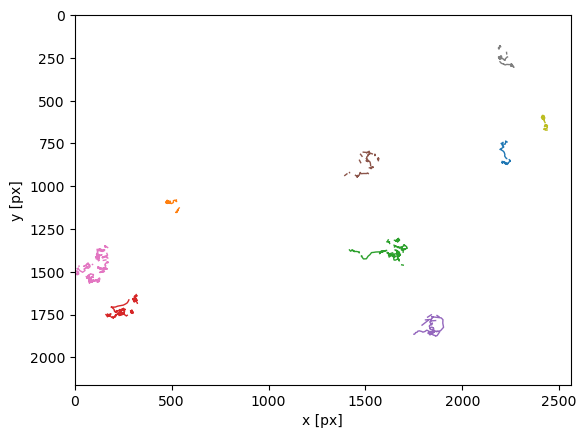

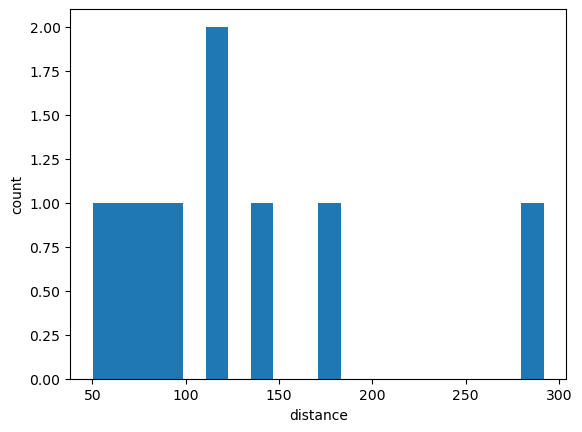

In [27]:
threshold = 20
import os
import sys
sys.path.append(os.path.abspath(".."))
from libs import remove_fixed as rf 

t2 = rf.remove_fixed(t1, threshold)

plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t2);

tracks_dist2 = rf.cal_dis(t2)

fig, ax = plt.subplots()
ax.hist(tracks_dist2["distance"], bins=20)

# Optionally, label the axes.
ax.set(xlabel='distance', ylabel='count');
os.makedirs(output, exist_ok=True)
#os.makedirs(output2, exist_ok=True)
t2.to_csv(f"{output}/beads_tracks.csv", index=False)
#t2.to_csv(f"{output2}/beads_tracks.csv", index=False)